In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=100, shuffle=False)
classes = val_dataset.classes

In [2]:
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.eval()
model = model.to(device)

activations = {}
def make_hook(name):
    def hook(module, input, output):
        activations[name] = F.adaptive_avg_pool2d(output, 1).flatten(1).detach().cpu()
    return hook

model.layer1.register_forward_hook(make_hook("early"))
model.layer3.register_forward_hook(make_hook("mid"))
model.layer4.register_forward_hook(make_hook("late"))

In [3]:
n_samples = 1500
early_feats, mid_feats, late_feats, labels = [], [], [], []

seen = 0
with torch.no_grad():
    for i, (images, targets) in enumerate(val_loader):
        model(images.to(device))
        early_feats.append(activations["early"])
        mid_feats.append(activations["mid"])
        late_feats.append(activations["late"])
        labels.append(targets)
        seen += targets.size(0)
        print(f"{seen}/{n_samples}")
        if seen >= n_samples:
            break

early_feats = torch.cat(early_feats)[:n_samples].numpy()
mid_feats = torch.cat(mid_feats)[:n_samples].numpy()
late_feats = torch.cat(late_feats)[:n_samples].numpy()
labels = torch.cat(labels)[:n_samples].numpy()

np.save("early_feats.npy", early_feats)
np.save("mid_feats.npy", mid_feats)
np.save("late_feats.npy", late_feats)
np.save("labels.npy", labels)

100/1500
200/1500
300/1500
400/1500
500/1500
600/1500
700/1500
800/1500
900/1500
1000/1500
1100/1500
1200/1500
1300/1500
1400/1500
1500/1500


In [4]:
early_feats = np.load("early_feats.npy")
mid_feats = np.load("mid_feats.npy")
late_feats = np.load("late_feats.npy")
labels = np.load("labels.npy")

running t-SNE on layer1 (early)...
running t-SNE on layer3 (mid)...
running t-SNE on layer4 (late)...


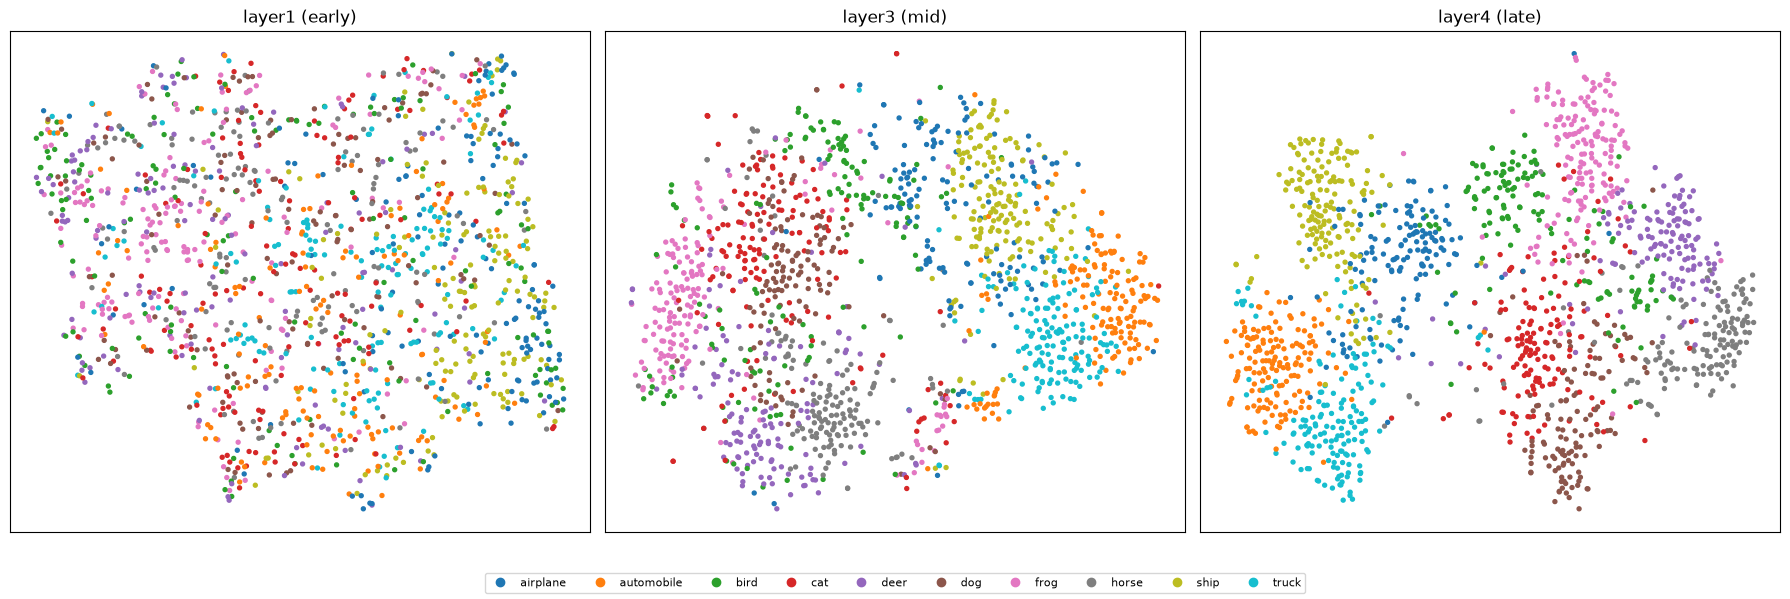

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feats, name in zip(axes, [early_feats, mid_feats, late_feats], ["layer1 (early)", "layer3 (mid)", "layer4 (late)"]):
    print(f"running t-SNE on {name}...")
    emb = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(feats)
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=8)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(i/9), label=c) for i, c in enumerate(classes)]
fig.legend(handles=handles, loc="lower center", ncol=10, fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("feature_hierarchy_tsne.png", dpi=150)
plt.show()